In [1]:
### imports
import numpy as np
import math
import random
import matplotlib.pyplot as plt
import scipy as sp

## Airfare Pricing with Repeated Games - Final Report
### Jerry Gammie
#### Table of Contents
#### 1. Introduction [(go to)](#s1)

#### 2. Methods
2.1. Data acquisition -- do some basic arithmetic used in slides/report here [(go to)](#s2_1) \
2.2. Volatility [(go to)](#s2_2) \
2.3. Price Discrimination through Fare Classes [(go to)](#s2_3) \
2.4. Repeated Play [(go to)](#s2_4) \
2.5. Passenger arrival time with Inhomogeneous Poisson Processes [(go to)](#s2_5) \
2.6. Be the Leader Strategies [(go to)](#s2_6) \
2.7. Core Simulation [(go to)](#s2_7)
#### 3. Results
3.1 Average Profit and Passenger Load Factor [(go to)](#s3_1) \
3.2 Simulated Arrival Times and True Rates [(go to)](#s3_2) \
3.3 Profit Over Time by Traveler Type [(go to)](#s3_3) \
3.4 Ticket Listing Prices [(go to)](#s3_4)
3.5 Sensitivity to Fuel Price Volatility [(go to)](#s3_5)
#### 4. Discussion [(go to)](#s4)

#### 5. Bibliography [(go to)](#s5)

## 1. Introduction
<a id='s1'></a>
At the inception of this project, I needed to buy an airline ticket to visit my sister in Philadelphia and help with her move. This planning coincided with world events that began to effect long-term airline ticket prices. I aimed to understand how airlines price tickets and to attempt to model their pricing mechanisms. The motivating example is thus a flight from Denver airport (DEN) to Washington Dulles airport (IAD) on May 13, 2026.
Only United Airlines (UA) and Southwest Airlines offer direct flights on this segment; United offers 8 flights on May 13 and Southwest offers 2. In simulations of airfare pricing, this near-monopoly is important to simplify modeling, because travelers looking for direct flights must book through UA or not fly this segment. 

<a id='s2_1'></a>
## 2. Methods
### 2.1. Data acquisition
I obtained general information about UA costs and profits from their 2025 Investor Relations Annual Report. I worked to estimate relevant ground truth values for this flight segment from the general, network-average values published in 2025. These include fuel cost per passenger (volatile), overhead cost per passenger (relatively involatile), and profit per passenger. The formula for computing fare price, and the scratchwork for estimating these values from the investor report and other sources, is performed below. I add additional "Taxi fuel" to the total fuel cost to account for the airplane not operating at peak cruising efficiency for a substantial portion of the distance, plus reserve fuel and the extra requirements of taxiing. This value is kept separate because it is not a factor in calculations involving revenue seat-miles.

In [ ]:
def fare_price(t, fare_k, x_fuel, volatility, base_opcost, base_profit, pax_fuel_quant):
    #print(x_fuel, volatility)
    fuelcost = pax_fuel_quant * (x_fuel + volatility * math.sqrt(t))
    return base_profit + base_opcost + fuelcost + fare_k


horizon = 120                       ### (days)
capacity = 200                      ### (passengers/plane)

flight_leg_length = 1500            ### compare to average stage length of 1488 miles
taxi_extra_fuel = 500               ### buffer -- extra fuel cost, since not all of the flight is at cruising efficiency
a321_hourly_fuelburn = 2200         ### kg/h
a321_cruising_speed = 509           ### mi/h
a321_airtime_den_iad = (flight_leg_length + taxi_extra_fuel)/a321_cruising_speed    ### airtime
fuel_kg_to_gallons = 0.3674         ### avgas weight (kg) to gallons
hourly_fuelburn_gallons = a321_hourly_fuelburn * fuel_kg_to_gallons
total_leg_fuelburn = a321_airtime_den_iad * hourly_fuelburn_gallons
print(total_leg_fuelburn, " <- total leg fuelburn")

baseline_fuel_cost = 2.44
capacity_321 = 200

fuelburn_per_pax = total_leg_fuelburn / capacity_321
print(fuelburn_per_pax, " <- fuelburn per passenger, gallons")
print(fuelburn_per_pax * baseline_fuel_cost, "<- average fuel cost per passenger, 2025")

revenue_per_seatmile = 0.1788
cost_per_seatmile = 0.1646
leg_cost_per_seat = cost_per_seatmile * flight_leg_length
print(leg_cost_per_seat, "<- cost per seat DEN-IAD, 2025")
overhead_cost_per_seat = leg_cost_per_seat - (fuelburn_per_pax * baseline_fuel_cost)
print(overhead_cost_per_seat, "<- overhead cost per seat (total cost - fuel cost)")
profit_per_seat = (revenue_per_seatmile - cost_per_seatmile) * flight_leg_length
print(profit_per_seat, "<- profit per seat DEN-IAD, 2025")
ua_px_rev = 59
ua_px_rev_mi = 271.6
px_weight = (190 / 2000) ### convert ntsb # to tons
ua_px_rev_ton_mi = ua_px_rev_mi * px_weight
ua_px_rptm = ua_px_rev / ua_px_rev_ton_mi

ua_cargo_rev = 1.8
ua_cargo_rev_ton_mi = 3.6
ua_cargo_rptm = ua_cargo_rev / ua_cargo_rev_ton_mi


print(ua_px_rev_ton_mi, ua_cargo_rev_ton_mi)
print(ua_px_rptm, ua_cargo_rptm, " <- revenue per ton-mile")



3175.9528487229863  <- total leg fuelburn
15.879764243614932  <- fuelburn per passenger, gallons
38.74662475442044 <- average fuel cost per passenger, 2025
246.9 <- cost per seat DEN-IAD, 2025
208.15337524557958 <- overhead cost per seat (total cost - fuel cost)
21.299999999999986 <- profit per seat DEN-IAD, 2025
25.802000000000003 3.6
2.2866444461669637 0.5  <- revenue per ton-mile


<a id='s2_2'></a>
### 2.2. Volatility
In order to include a measure of volatility, I attempted to estimate the current price increase due to volatility with a simplification of Black-Scholes, thanks to [8], and verified against [9, 10]. U.S. airlines do not do meaningful fuel hedging [12], so they have to buy at the price at the time of the flight, that being the expected cost. So I compute the volatility-adjusted fuel cost with
$$
F_{est} \approx \mathbb{E}[F] + \sigma \sqrt(\tau)
$$
Where $\sigma$ is the implied volatility, $\mathbb{E}[F]$ is the expected fuel cost at the time of the flight, and $\tau$ the remaining time until the flight. Assuming $\mathbb{E}[F]$ is UA’s average price in 2025, the volatility-adjusted prices are shown in figure 1:

Figure 1. Volatility-Adjusted fuel prices.

![Figure 1](projfigs/volatility.png)

The volatility price adjustment and price functions are implemented both below, and in section 2.1 for fare_price calculation:

In [ ]:
### adjust fuel prices by volatility
def vol_adjustment(t, sigma):
    return sigma * math.sqrt(t)

### return constant implied volatility
def vol_constant(t, sigma):
    #print("*", t, sigma)
    return sigma[1]

### we want to check a jump in volatility partway through
def vol_jump(t, vparams):
    t_jump, sigma1, sigma2 = vparams
    if t < t_jump:
        return sigma1
    else:
        return sigma2

### return constant fuel cost
def fuel_cost_const(t, f):
    #print("*", t, f)
    return f[1]

### return a jump in expected fuel cost
def fuel_cost_jump(t, fparams):
    t_jump, f1, f2 = fparams
    if t < t_jump:
        return f1
    else:
        return f2


<a id='s2_3'></a>
### 2.3. Price Discrimination through Fare Classes
Airlines notoriously use dynamic and targeted pricing, but these mechanisms are kept secret. What we do know is that airlines use fare classes for price discrimination. An description of fare classes from Belobaba [6], and their analogues in my simulation, are outlined below in table 3. I implemented a baseline of 10 fare classes that loosely correspond to these, based on the dollar increase over the baseline per-seat airline operation cost. Although Belobaba’s numbers date from the 1980s, we see similar stratification between amenities and what people are willing to pay for first class and steerage. At the time of writing this report, on a medium-horizon DEN-IAD flight, First class is offered for $444, Economy Plus for $350, Economy (Full) for $224, Economy for $184, and Basic Economy for $139. Targeted demand categories are described in section 2.5. 

Table 4. Fare class overview.
| Fare Product (Belobaba) | Targeted Demand | Approximate Price (% Relative to Coach, Belobaba) | Implemented Fare Classes |
|----------|----------|----------|----------|
| First    | Type 1     | 150     | A - 400     |
| Business    | Type 1     | 110     | B = 250     |
| Full Coach    | Type 1      | 100     | C - 150     |
| Super Coach    | Type 2    | 70-85  |  D - 100   |
| Excursion    | Type 2    | 50-70     |  E - 70, F - 50    |
| Super Saver    | Type 3     | 30-50     |  G - 30, H - 10     |
| "MAx Saver"    | Type 3    | 20-30     | I - 0, J - -10    |

In [4]:
fare_class_table = [-10,
                    0,
                    10,
                    30,
                    50,
                    70,
                    100,
                    150,
                    250,
                    400]

<a id='s2_4'></a>
### 2.4. Repeated play
I model airline ticket pricing as a repeated play game, where each turn is an instance where a prospective passenger visits the airline website. Each turn, the airline plays first, picking a fare class to present to the passenger. The precise amount quoted is the sum of the airline’s base cost, the expected fuel cost per passenger at time of the request, and the fare class profit from table 4. The payoff to the airline is the fare class profit if the passenger purchases the ticket, and $0 otherwise. 
The passenger plays second. Each passenger visiting the website has a traveler trip utility sampled from a distribution (see section 2.5). The traveler sees the quoted airfare and chooses to purchase it if the difference between their trip utility and the published airfare is positive, in which case that difference is their payoff, and will not purchase otherwise, in which case their payoff is 0. 
The game stops when all seats are sold, or the time horizon is reached, whichever occurs first. I arbitrarily set the time horizon to 120 days.

<a id='s2_5'></a>
### 2.5. Passenger arrival time with Inhomogeneous Poisson Processes
To model prospective passengers in the repeated play game, I aim to take into account spending propensity (how much passengers are willing to pay for a ticket, or how likely they are to purchase a ticket given the offered price), and how these propensities will change over the time between the first listing of the flight and the time horizon, the day of the flight. Belobaba [6] defines 4 types of passengers based on their time and price sensitivity. I attempt to extend these categories to when these types of travelers attempt to book tickets to model passenger purchasing behavior and to capture contrived trends and behaviors that I arbitrarily attribute to travelers with:

- Latent demand for travel (Belobaba Type 3, price-sensitive and time-insensitive). People generally will want to go somewhere around the target time but will not be willing to spend a lot. This demand doesn’t change over time. This corresponds to is modeled through the archetype of the “Graduate Student”

- Early Deal Seekers (Belobaba Type 2, time-sensitive and price-sensitive). People who want to travel somewhere around a known time will look months in advance to try to secure a deal, but will not be able to plan longer in advance. However, they will not risk a last minute purchase, because many people have as a prior that ticket costs increase closer to the flight. This is modeled through the archetype of the “Leisure Traveller”

- High-propensity planners (Belobaba Type 1, insensitive to time or price). People who know ahead of time that they need to be somewhere and value direct flights will be willing to spend more to get a direct flight. This could include first-class reservations. This is modeled through the archetype of the “Business Traveler”

- Last-minute gouging (Belobaba Type 4, time-sensitive and insensitive to price). Some people will have to make emergency trips and will be willing to pay extortionate prices to book travel right beforehand. This is modeled through the archetype of the “Emergency Traveler”

These classifications of passengers are also based in part on the summary of revenue management strategies for airline inventory in Burger and Fuchs [5], who summarize that historical revenue management sought to obtain revenue from leisure travelers on cheaper fares without forgoing higher per-seat revenue from business travelers willing and able to pay more. The key problem in this historical formulation was the assumption that leisure travelers would seek to book first, before the demand from business travelers was known. Different fare classes target different traveler types (see table 3), with last-minute Type 4 travelers booking any fare class they can. 

In the repeated play game, each turn occurs when a prospective passenger visits the airline website to check the price of a ticket on this segment. Because the latter three archetypes’ behaviors depend on the time before the flight, I must model site visits over time. This is achieved, because of the variable arrival rates over time, through Inhomogeneous Poisson Point Processes (IPPPs). A Poisson Point Process with rate $\lambda$ models the number of arrivals in a time window (t+s, t) as being poisson-distributed with rate $\lambda s$; an IPPPs models the number of arrivals in (t+s, t) as being poisson-distributed with rate ([4])
$$
\int_t^{t+s} \lambda(u) du
$$

For each archetype, I constructed an arbitrary rate function that exhibits the behaviors described above,
$$
\lambda_{Grad}(t) = g
$$
$$
\lambda_{Business}(t) = \frac{8b^3}{(t-30)^2 + 4b^2} - \frac{t}{60} + 2 + \frac{10}{t+3}
$$
$$
\lambda_{Leisure}(t) = \sin(\pi (\frac{t}{110})^3) + \frac{t}{120}
$$
$$
\lambda_{Emergency}(t) = e^{-(\frac{x}{m})^2}
$$
Where g, b, and m are constant parameters to the rate function to experiment with the shapes of the functions. Again, t is the time (in days) before the flight. In practice, I used g=1, b=0.3, and m=8. The rate functions are implemented below, and are plotted in figure 2 further below. 

In [5]:
### 2.5 Arrival Rates
### return rate for each passenger archetype
def lambda_grad(t, g):
    return g

def lambda_business(t, b):
    return ((8*(b ** 3))/(((t - 30) ** 2) + 4 * (b ** 2) )) - (t/60) + 2 + (10/(t+3))

def lambda_leisure(t, _):
    return (math.sin(math.pi * ((t/110) ** 3)) + (t/120))

def lambda_emergency(t, m):
    return math.exp(- ((t/m) ** 2))

I scaled these rate functions with coefficients $\beta$ to adjust the arrival rates to intuitive, but arbitrarily chosen, proportions of the total arrivals (there should be more low-propensity inquiries than high propensity inquiries). I set 

$\beta_{Grad} = 10$,  $\beta_{Business} = 0.3$,  $\beta_{Leisure} = 6$,  $\beta_{Emergency} = 8$.

Simulated website visit frequencies over the time window for each traveler archetype are shown in figure 3. 

Figure 2. IPPP Traveler Archetype Arrival Rates

![Figure 2](projfigs/arrival_rates.png)

Figure 3. Simulation of Arrival Frequencies

![Figure 3](projfigs/example_inquiries.png)

As desired to match intuition, there is generally consistent latent demand (blue), with early-window deal hunters peaking and decreasing around 90 days out (green), high-propensity planners arriving most frequently around 30 days out (orange - but not as frequently as other traveler types, since there are less rich people in the general population), and emergency travelers peaking right before the flight.

IPPPs can be modeled numerically through thinning of Homogeneous Poisson Point Processes (HPPPs). For each process, I find the maximum value of the time-dependent rate function over the time window. I computed these maxima, $\Lambda_{Grad}$, $\Lambda_{Business}$, $\Lambda_{Leisure}$, and $\Lambda_{Emergency}$ over the time window [0, 120]. I then simulate each traveler archetype arrival with a HPPP with rate $\Lambda_{arch}$ (for each archetype) and accept an arrival at time t with probability
$$
Prob\{Accept | Time=t\} = \frac{\lambda_{arch}(t)}{\Lambda_{arch}}
$$
Inter-arrival times for these HPPPs are exponentially distributed with rate $\frac{1}{\Lambda_{arch}}$, so for each archetype, I repeatedly sample from the exponential distribution and compute the running total time $\tau$, compute $\lambda_{arch}(H -\tau)$ for the window opening time H, and accept with probability $\frac{\lambda_{arch}(H -\tau)
}{\Lambda_{arch}}$ for each archetype to sample a list of arrival times for each passenger archetype. The sampling algorithm is implemented below.


In [6]:
### sample inhomogeneous poisson point process
def sample_ippp(lambda_ts, lambda_params, beta, big_lambda, t, horizon_lim):
    ### sample exp...
    total_inter = 0
    while total_inter < horizon_lim:
        ### sample interarrival time at max frequency
        s = np.random.exponential(1/big_lambda)
        total_inter += s
        ### keep sample w.p. lambda_t/lambda_max
        u = random.random()
        if u < beta * lambda_ts(horizon_lim-(t+total_inter), lambda_params) / big_lambda:
            break
    return total_inter

Each traveler archetype samples their trip utility, $U_{arch}$, used to determine their move in the repeated play game from a different distribution:
$$
U_{Grad} \sim \mathcal{N} (\mu = 100, \sigma = 20)
$$
$$
U_{Business} \sim U (200, 500)
$$
$$
U_{Leisure} \sim \mathcal{N} (\mu = 120, \sigma = 50)
$$
$$
U_{Emergency} \sim \begin{cases}
10000 & \text{with probability } 0.7 \\
200 & \text{with probability } 0.3
\end{cases}
$$
These distributions govern how much each traveler archetype will be willing to pay once they see the airfare quoted by the airline. The precise distributions are chosen arbitrarily, based on a personal estimate of how much each traveller archetype is willing to spend. Utility sampling is implemented below for each archetype.

In [7]:
### utility functions for each archetype
def utility_grad(para):
    return np.random.normal(para[0], para[1])

def utility_business(para):
    return np.random.uniform(para[0], para[1])

def utility_leisure(para):
    return np.random.normal(para[0], para[1])

def utility_emergency(para):
    u = random.random()
    if u < para[0]:
        #print(u)
        return 10000
    else:
        return 200
    
def airline_util(base_profit, fare_profit):
    #fuelcost = exp_fuel + volatility * math.sqrt(t)
    return base_profit + fare_profit

<a id='s2_6'></a>
### 2.6. Be the Leader Strategies
The airline moves first in this repeated play game. I experimented with three strategies for picking the published fare class: uniform, max-expectation, and class-availability. The uniform strategy is the simplest mixed strategy where the airline selects one of the fare classes uniformly at random. The class-availability strategy is a fixed strategy whereby the airline allocates 20 seats for each fare class. This is based on the seating arrangement in the UA A321neo and conveniently consistent with 10 total fare classes in my experiment; There are 20 first class seats (fare type A, table 4), 57 "economy plus” seats (approximately 60 - fare types B, C, D, table 4), with the remainder being economy seats (fare classes E, F, G, H, I, J, table 4). The airline publishes class J tickets until 20 are sold, then class I tickets until 40 are sold, and so on. 

The max-expectation strategy assumes that the airline has conducted market research and knows the arrival rates of each passenger archetype, and the distributions of their travel utilities. At the time  of each request, the airline estimates the arrival rates of each passenger archetype, $\lambda_{arch}(\tau)$, and normalized to obtain the probability that the unknown traveller belongs to each archetype. For each archetype, the algorithm computes the expected payoff from listing each fare class (this is the product of the probability of purchase, $P_{arch}$, and the profit for fare class i, $V_{i}$), and weights the expected payoffs by the visiting probabilities:
$$
\mathbb{E}[V_i] = \sum_{arch} \lambda_{arch}(\tau)V_i* Prob\{U_{arch} > V_i + C(\tau)\}
$$

Where $C(\tau)$ is the sum of fixed costs and fuel costs at time $\tau$, per passenger. The airline follows a mixed strategy, sampling each fare class based on the normalized expected payoffs. Every quoted fare price over one simulation is shown in figure 4, and daily average fare prices are shown in figure 5.
 
Figure 4. All Quoted Fare Prices

![Figure 4](projfigs/total_listings.png)

Figure 5. Daily Average Quoted Fare Prices

![Figure 5](projfigs/avg_daily.png)

The pricing strategies are implemented below.

In [8]:
### pricing strategies
def pricing_uniform(_):
    return random.randint(0, 9)

def uniform_check(x, mi, ma):
    if x < mi:
        return 0
    elif x < ma:
        return 1-(x-mi)/(ma-mi)
    else:
        return 1
    
### only offer the cheapest until we sell out, then the next, etc...
def farebuckets(nsold):
    ### nsold, bucket sizes, max capacity
    return min(nsold[0], nsold[2]-1) // nsold[1]

### max - expectation pricing. Somewhat hard-coded for now...
def pricing_exp(peparams):
    ### unpack params from list
    t, sampler_list, scales, sparams, utilparams, fct, exp_fuel, vol, ops, base_profit, pfq = peparams
    ### expected at time t: 
    relative_s = []
    for i in range(4):
        trs = sampler_list[i]
        #print(type(trs))
        relative_s.append(scales[i] * trs(t, sparams[i]))
    rssum = sum(relative_s)
    ### prob. of each appearing
    relative_s = [ii / rssum for ii in relative_s]
    ### exp. of each typer
    weights = []
    for i in range(len(fct)):
        temp = fare_price(t, fct[i], x_fuel=exp_fuel, volatility=vol, 
                                base_opcost=ops, base_profit=base_profit, pax_fuel_quant=pfq)
        exps = [sp.stats.norm.sf(temp, loc=utilparams[0][0], scale=utilparams[0][1]),
                uniform_check(temp, utilparams[1][0], utilparams[1][1]), 
                sp.stats.norm.sf(temp, loc=utilparams[2][0], scale=utilparams[2][1]), 
                0.7*fct[i]]
        weighted = [exps[ii] * relative_s[ii] for ii in range(4)]
        weights.append(sum(weighted))
    sw = sum(weights)
    weights = [elt/sw for elt in weights]
    samplefrom = [ii for ii in range(10)]

    ### randomly sample based on 
    return random.choices(samplefrom, weights=weights)[0]


<a id='s2_7'></a>
### 2.7. Core Simulation

In [9]:
def run_simulation(pricing_list, n_sims, time_horizon, rateparams, betas, utilparams, fare_classes, expfuel_func, vol_func, pax_fuel_quant, ops_cost, base_margin, capacity, func_params):
    ### set up arrays to store results
    listingpricehist = [[] for jj in range(len(pricing_list))]
    listingtimehist = [[] for jj in range(len(pricing_list))]
    lpdayhist = [[0 for ii in range(time_horizon)] for jj in range(len(pricing_list))]
    ltdayhist = [[0 for ii in range(time_horizon)] for jj in range(len(pricing_list))]
    avg_profits = [0 for jj in range(len(pricing_list))]
    avg_pax = [0 for jj in range(len(pricing_list))]

    visits = [[] for jj in range(len(pricing_list))]
    visits_binned = [[] for jj in range(len(pricing_list))]
    sold_classes = [[] for jj in range(len(pricing_list))] #
    profit_classes = [[] for jj in range(len(pricing_list))]
    ### compute max frequencies
    ### these are definitely hard-coded to the time range [0, 120]
    lambdas_max = [lambda_grad(1, rateparams[0]) * betas[0],
                betas[1] * max(lambda_business(0, rateparams[1]), lambda_business(30, rateparams[1])),
                betas[2] * lambda_leisure(89.93277, rateparams[2]),
                betas[3] * lambda_emergency(0, rateparams[3])]
    ### list the rates for each archetype
    rates_list = [lambda_grad, lambda_business, lambda_leisure, lambda_emergency]
    util_dists = [utility_grad, utility_business, utility_leisure, utility_emergency]
    

    for price_strat in range(len(pricing_list)):
        for n in range(n_sims):
            ### sample first time step for ippp
            inter_arr = np.array([sample_ippp(rates_list[ii], rateparams[ii], betas[ii], lambdas_max[ii], 0, time_horizon) for ii in range(len(rates_list))])
            visits[price_strat].append([0, 0, 0, 0])
            visits_binned[price_strat].append(np.array([[0 for ii in range(time_horizon)], [0 for ii in range(time_horizon)], 
                                                        [0 for ii in range(time_horizon)], [0 for ii in range(time_horizon)]]))
            profit_int = 0
            sold_seats = 0
            sold_classes[price_strat].append([[0 for ii in range(time_horizon)], [0 for ii in range(time_horizon)],
                               [0 for ii in range(time_horizon)], [0 for ii in range(time_horizon)]])
            profit_classes[price_strat].append([[0 for ii in range(time_horizon)], [0 for ii in range(time_horizon)],
                                 [0 for ii in range(time_horizon)], [0 for ii in range(time_horizon)]])
            while True:
                ### sample each pp -- see which archetype is the next to arrive
                nextup = np.argmax(time_horizon - inter_arr)
                ### if the next to arrive is after the time horizon, exit
                tau = time_horizon - inter_arr[nextup]
                if tau <= 0:
                    break
                else:
                    ### otherwise, we have the next arrival...
                    ### keep track of which archetype visited:
                    visits[price_strat][n][nextup] += 1
                    visits_binned[price_strat][n][nextup][int(tau)] += 1
                    
                    ### now...
                    ### determine if they buy
                    ### t, fare_k, x_fuel, volatility, base_opcost, base_profit
                    ### package params to feed to utility function
                    strat_params = [[None],
                                    [int(tau), rates_list, betas, rateparams, utilparams, fare_classes, expfuel_func(tau, func_params[0]), 
                                     vol_func(tau, func_params[1]), ops_cost, base_margin, pax_fuel_quant],
                                    [sold_seats, capacity//len(fare_classes), capacity-1]]
                    #t, sampler_list, scales, sparams, fct, exp_fuel, vol, ops, base_profit
                    ### determine which fare class the airline should play
                    pricing_play = pricing_list[price_strat](strat_params[price_strat])

                    ### wrapped this in try/catch because...
                    ### there are some edge cases where this was erroring out... should not happend anymore
                    try:
                        #print(price_strat, pricing_play)
                        #print(fare_class_table[pricing_play])
                        #print(expfuel_func(tau, func_params[0]))
                        #print(vol_func(tau, func_params[1]))
                        list_price = fare_price(tau, fare_class_table[pricing_play], x_fuel=expfuel_func(tau, func_params[0]), volatility=vol_func(tau, func_params[1]), 
                                                base_opcost=ops_cost, base_profit=base_margin, pax_fuel_quant=pax_fuel_quant)
                    except:
                        print("uh oh", pricing_play)

                    ### keep track of posted prices for analysis...
                    ### for all listings
                    listingpricehist[price_strat].append(list_price)
                    listingtimehist[price_strat].append(tau)
                    ### avg for each day
                    lpdayhist[price_strat][int(tau)] += list_price
                    ltdayhist[price_strat][int(tau)] += 1
                    ### compute customer util
                    customer_util = util_dists[nextup](utilparams[nextup])
                    #print(customer_util)

                    ### customer buys if util exceeds price, and there are seats left
                    if customer_util > list_price and sold_seats < capacity: 
                        ### adjust profit earned by airline
                        profit_int += base_margin + pricing_play
                        sold_seats += 1
                        sold_classes[price_strat][n][nextup][int(tau)] += 1
                        profit_classes[price_strat][n][nextup][int(tau)] += base_margin + pricing_play
                    ### customer does not buy otherwise
                    else:
                        ### do nothing?
                        pass
                    ### sample next arrival for this archetype
                    inter_arr[nextup] += sample_ippp(rates_list[nextup], rateparams[nextup], betas[nextup], lambdas_max[nextup], inter_arr[nextup], time_horizon)
            avg_profits[price_strat] += profit_int
            avg_pax[price_strat] += sold_seats
                
        avg_profits[price_strat] /= n_sims
        avg_pax[price_strat] /= n_sims
        
    return avg_profits, avg_pax, visits, visits_binned, sold_classes, profit_classes, listingpricehist, listingtimehist, lpdayhist, ltdayhist

Run a small test simulation with default everything:

In [10]:
### standard values:
# pricing_list, n_sims, time_horizon, rateparams, betas, utilparams, fare_classes, expfuel_func, vol_func, ops_cost, base_margin, capacity, func_params
res_test = run_simulation(pricing_list=[pricing_uniform, pricing_exp, farebuckets],
                          n_sims=1,
                          time_horizon=horizon,
                          rateparams=[1, 3, -1, 8],
                          betas=[10, 0.3, 6, 8],
                          utilparams=[[100, 20], [200, 500], [120, 50], [0.7]],
                          fare_classes=fare_class_table,
                          expfuel_func=fuel_cost_const,
                          vol_func=vol_constant,
                          pax_fuel_quant=fuelburn_per_pax,
                          ops_cost=overhead_cost_per_seat,
                          base_margin=0,
                          capacity=capacity_321,
                          func_params=[[None, baseline_fuel_cost],
                                       [None, 0.01]])

<a id='s3_1'></a>
## 3. Results
### 3.1 Average Profit and Passenger Load Factor
Below, I run 1000 simulations to compute the mean profit per flight for the airline and the mean passenger count per flight. Compare these averages to the estimated true profit for this flight ($21.3/seat, or $4260 for the flight) and the airline average passenger load factor (0.822, or 164 passengers on this flight)

[302.535, 405.223, 240.416] [82.8, 79.96, 107.784]


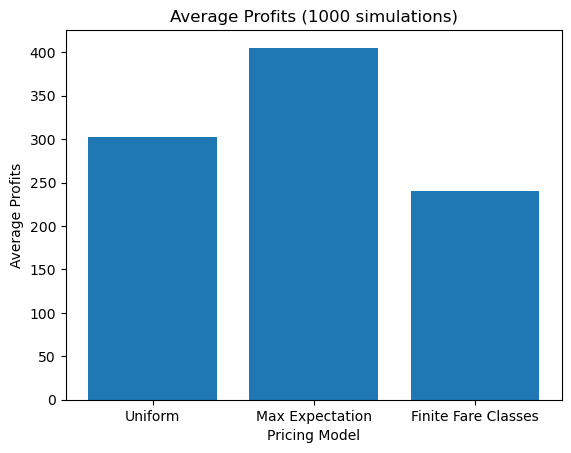

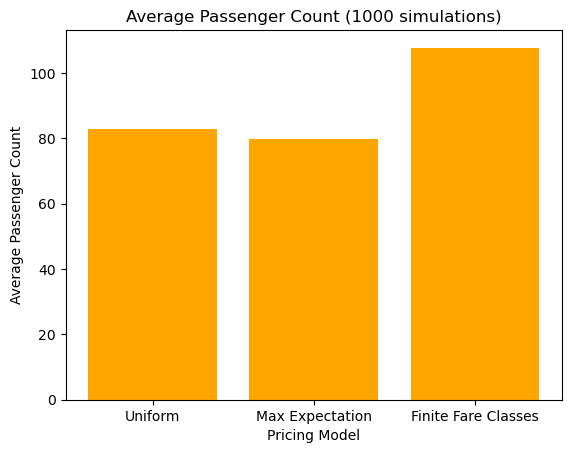

In [11]:
avg_nsims = 1000
avg_results = run_simulation(pricing_list=[pricing_uniform, pricing_exp, farebuckets],
                          n_sims=avg_nsims,
                          time_horizon=horizon,
                          rateparams=[1, 3, -1, 8],
                          betas=[10, 0.3, 6, 8],
                          utilparams=[[100, 20], [200, 500], [120, 50], [0.7]],
                          fare_classes=fare_class_table,
                          expfuel_func=fuel_cost_const,
                          vol_func=vol_constant,
                          pax_fuel_quant=fuelburn_per_pax,
                          ops_cost=overhead_cost_per_seat,
                          base_margin=0,
                          capacity=capacity_321,
                          func_params=[[None, baseline_fuel_cost],
                                       [None, 0.01]])

avpr = avg_results[0]
avpx = avg_results[1]
strat_headers = ["Uniform", "Max Expectation", "Finite Fare Classes"]
print(avpr, avpx)
plt.bar(strat_headers, avpr)
plt.title("Average Profits (" +str(avg_nsims) + " simulations)")
plt.xlabel("Pricing Model")
plt.ylabel("Average Profits")
plt.show()

plt.bar(strat_headers, avpx, color="orange")
plt.title("Average Passenger Count (" +str(avg_nsims) + " simulations)")
plt.xlabel("Pricing Model")
plt.ylabel("Average Passenger Count")
plt.show()

<a id='s3_2'></a>
### 3.2 Simulated Arrival Times and True Rates
Below, I plot the arrival times for one process and the deterministic arrival rates.

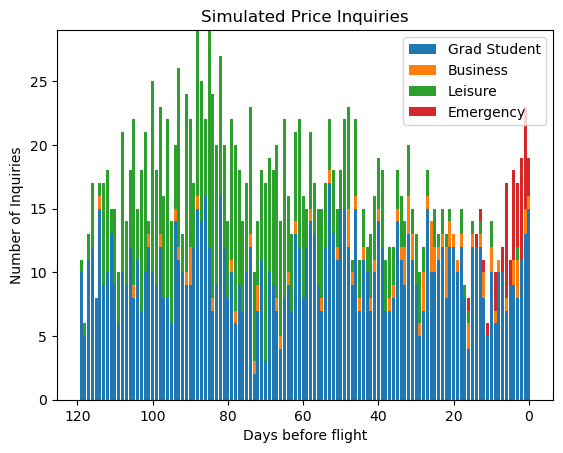

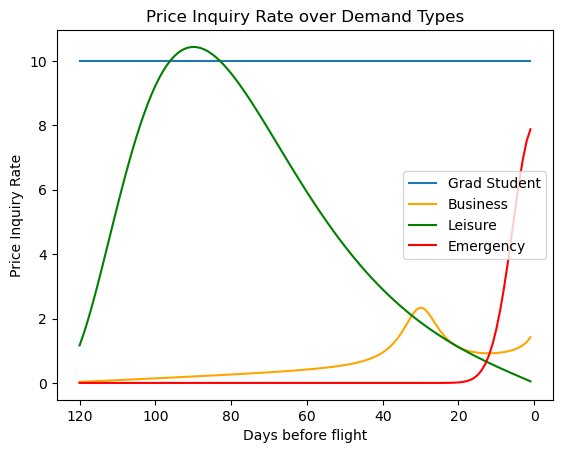

In [12]:
single_results = run_simulation(pricing_list=[pricing_uniform, pricing_exp, farebuckets],
                          n_sims=1,
                          time_horizon=horizon,
                          rateparams=[1, 3, -1, 8],
                          betas=[10, 0.3, 6, 8],
                          utilparams=[[150, 50], [250, 600], [180, 80], [0.7]],
                          fare_classes=fare_class_table,
                          expfuel_func=fuel_cost_const,
                          vol_func=vol_constant,
                          pax_fuel_quant=fuelburn_per_pax,
                          ops_cost=overhead_cost_per_seat,
                          base_margin=0,
                          capacity=capacity_321,
                          func_params=[[None, baseline_fuel_cost],
                                       [None, 0.01]])
#return avg_profits, avg_pax, visits, visits_binned, sold_classes, profit_classes, listingpricehist, listingtimehist, lpdayhist, ltdayhist
vb = single_results[3][0][0]

x_p = [ii for ii in range(horizon)]
plt.bar(x_p, vb[0], label="Grad Student")
plt.bar(x_p, vb[1], bottom=vb[0], label="Business")
plt.bar(x_p, vb[2], bottom=vb[0] + vb[1], label="Leisure")
plt.bar(x_p, vb[3], bottom=vb[0] + vb[1] + vb[2], label="Emergency")
plt.gca().invert_xaxis()

plt.title("Simulated Price Inquiries")
plt.xlabel("Days before flight")
plt.ylabel("Number of Inquiries")
plt.legend()
plt.show()

x_p = [horizon - ii for ii in range(horizon)]
plt.plot(x_p, [10 * lambda_grad(horizon - ii, 1) for ii in range(horizon)], label="Grad Student")
plt.plot(x_p, [0.3 * lambda_business(horizon - ii, 3) for ii in range(horizon)], color="orange", label="Business")
plt.plot(x_p, [6 * lambda_leisure(horizon - ii, -1) for ii in range(horizon)], color="green", label="Leisure")
plt.plot(x_p, [8 * lambda_emergency(horizon - ii, 8) for ii in range(horizon)], color="red", label="Emergency")

plt.gca().invert_xaxis()

plt.title("Price Inquiry Rate over Demand Types")
plt.xlabel("Days before flight")
plt.ylabel("Price Inquiry Rate")
plt.legend()
plt.show()

<a id='s3_3'></a>
### 3.3 Profit Over Time by Traveler Type
Below, I plot the total profit accrued by the airline over time, broken down by the fare class of the purchasers, over one simulation.

In [13]:
p_i = []
for i in range(3):
    profit_i = single_results[5][i][0]
    profit_i = np.array(profit_i)
    #print(profit_i.shape)
    for i in range(len(profit_i)):
        for j in range(len(profit_i[i])):
            profit_i[i, j] = np.sum(profit_i[i, j:])
    #print(profit_i.shape)
    #print(profit_i[3])
    p_i.append(profit_i)

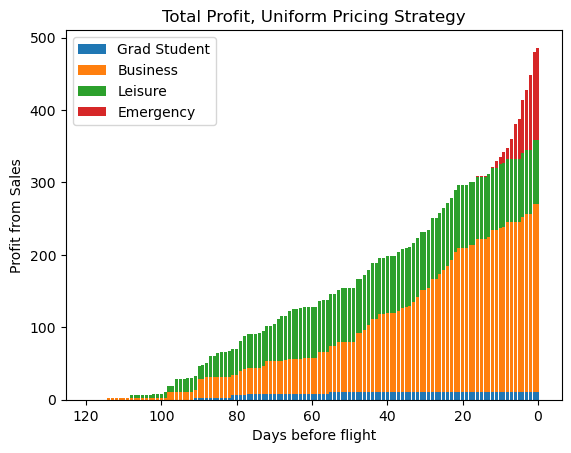

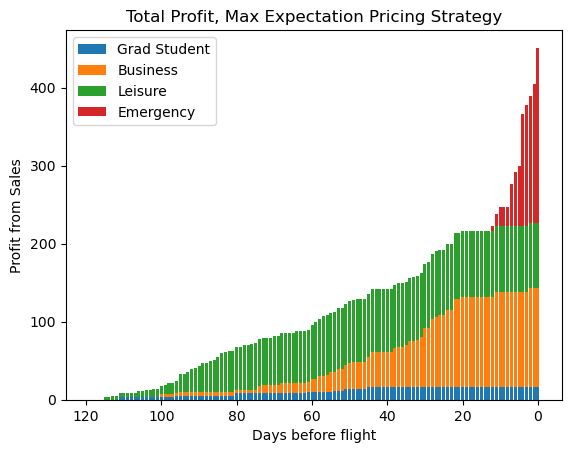

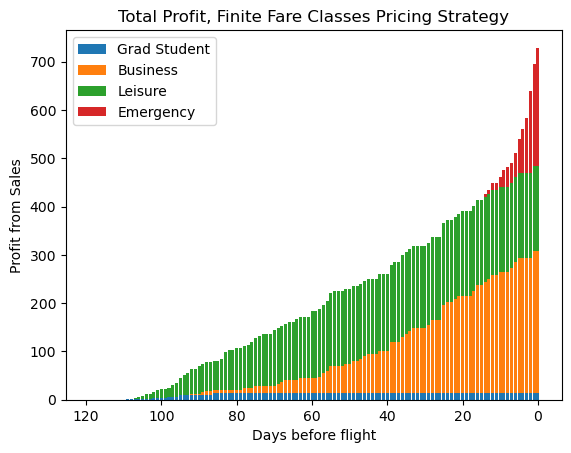

In [14]:
#strat_headers
for i in range(3):
    #profit_i = single_results[5][i][0]
    profit_i = p_i[i]
    x_p = [ii for ii in range(horizon)]
    profit_i = np.array(profit_i)
    plt.bar(x_p, profit_i[0], label="Grad Student")
    plt.bar(x_p, profit_i[1], bottom=profit_i[0], label="Business")
    plt.bar(x_p, profit_i[2], bottom=profit_i[0] + profit_i[1], label="Leisure")
    plt.bar(x_p, profit_i[3], bottom=profit_i[0] + profit_i[1] + profit_i[2], label="Emergency")

    plt.gca().invert_xaxis()

    plt.title("Total Profit, " + strat_headers[i] + " Pricing Strategy")
    plt.xlabel("Days before flight")
    plt.ylabel("Profit from Sales")
    plt.legend()
    plt.show()

<a id='s3_4'></a>
### 3.4 Ticket Listing Prices
Below, I plot the ticket listing prices over time for each pricing strategy (First the average daily ticket prices, then all ticket prices quoted). Compare to the baseline observed ticket price time series from Google flights (Figure 6).

Figure 6. UA DEN-IAD Historical Prices for Day-of Flight
![Figure 6](projfigs/googleflights.png)

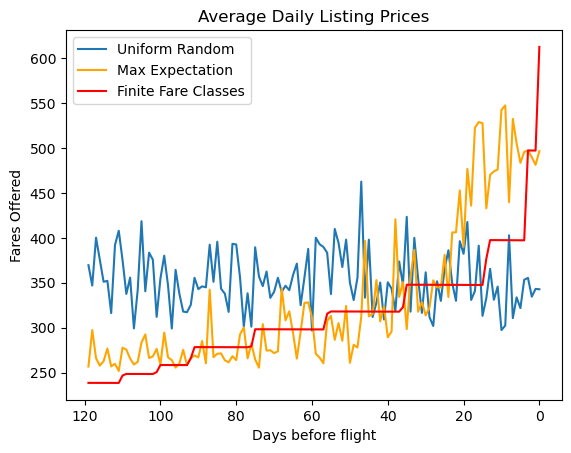

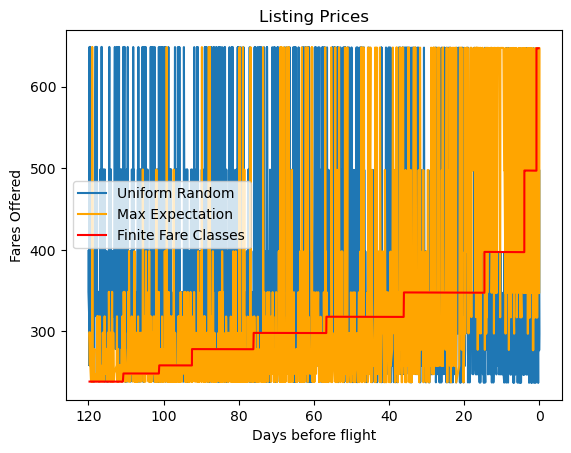

In [15]:
# listingpricehist, listingtimehist, lpdayhist, ltdayhist 6
lpday = single_results[8]#[i][0]
ltday = single_results[9]#[i][0]
lphist = single_results[6]#[i][0]
lthist = single_results[7]#[i][0]

plt.plot(x_p, [lpday[0][ii] / ltday[0][ii] for ii in range(horizon)], label="Uniform Random")
plt.plot(x_p, [lpday[1][ii] / ltday[1][ii] for ii in range(horizon)], color='orange', label="Max Expectation")
plt.plot(x_p, [lpday[2][ii] / ltday[2][ii] for ii in range(horizon)], color='red', label="Finite Fare Classes")
plt.legend()
plt.xlabel("Days before flight")
plt.ylabel("Fares Offered")
plt.title("Average Daily Listing Prices")

plt.gca().invert_xaxis()
plt.show()

plt.plot(lthist[0], lphist[0], label="Uniform Random")
plt.plot(lthist[1], lphist[1], color='orange', label="Max Expectation")
plt.plot(lthist[2], lphist[2], color='red', label="Finite Fare Classes")
plt.legend()
plt.xlabel("Days before flight")
plt.ylabel("Fares Offered")
plt.title("Listing Prices")

plt.gca().invert_xaxis()
plt.show()

<a id='s3_5'></a>
### 3.5 Sensitivity to Fuel Price Volatility
Below, I experiment with model sensitivity to changing fuel costs and changing fuel cost implied volatility over the time window. First, I plot a increase in fuel prices, then a decrease, both with high baseline volatility. Finally, I plot a dramatic increase in volatility with a small increase in fuel price. 

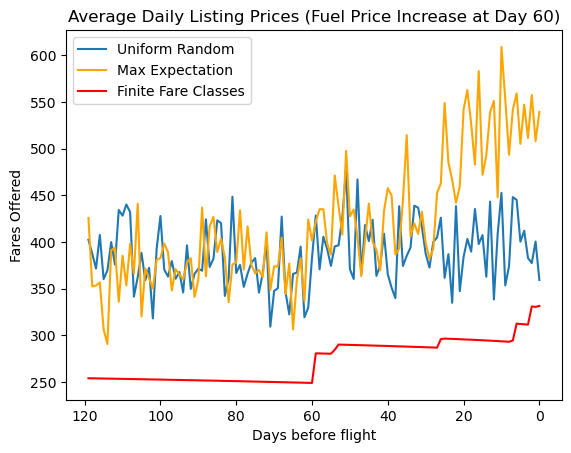

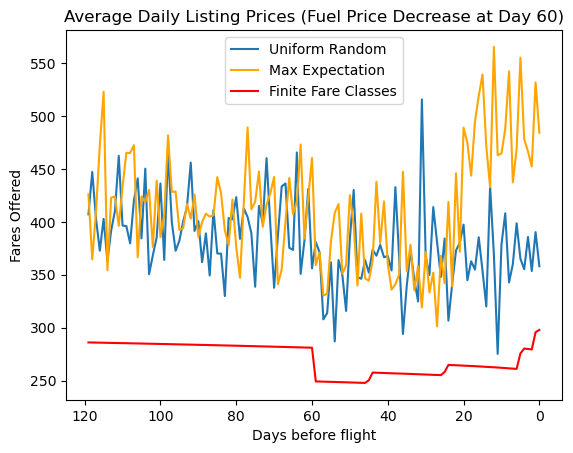

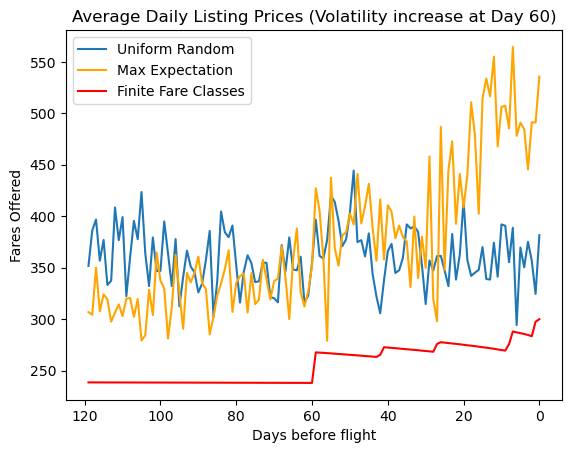

In [16]:
volatility_shock = run_simulation(pricing_list=[pricing_uniform, pricing_exp, farebuckets],
                            n_sims=1,
                            time_horizon=horizon,
                            rateparams=[1, 3, -1, 8],
                            betas=[10, 0.3, 6, 8],
                            utilparams=[[100, 20], [200, 500], [120, 50], [0.7]],
                            fare_classes=fare_class_table,
                            expfuel_func=fuel_cost_jump,
                            vol_func=vol_constant,
                            pax_fuel_quant=fuelburn_per_pax,
                            ops_cost=overhead_cost_per_seat,
                            base_margin=0,
                            capacity=capacity_321,
                            func_params=[[60, baseline_fuel_cost+2, baseline_fuel_cost],
                                        [None, 0.1]])

lpday = volatility_shock[8]#[i][0]
ltday = volatility_shock[9]#[i][0]
lphist = volatility_shock[6]#[i][0]
lthist = volatility_shock[7]#[i][0]

plt.plot(x_p, [lpday[0][ii] / ltday[0][ii] for ii in range(horizon)], label="Uniform Random")
plt.plot(x_p, [lpday[1][ii] / ltday[1][ii] for ii in range(horizon)], color='orange', label="Max Expectation")
plt.plot(x_p, [lpday[2][ii] / ltday[2][ii] for ii in range(horizon)], color='red', label="Finite Fare Classes")
plt.legend()
plt.xlabel("Days before flight")
plt.ylabel("Fares Offered")
plt.title("Average Daily Listing Prices (Fuel Price Increase at Day 60)")

plt.gca().invert_xaxis()
plt.show()

volatility_shock = run_simulation(pricing_list=[pricing_uniform, pricing_exp, farebuckets],
                            n_sims=1,
                            time_horizon=horizon,
                            rateparams=[1, 3, -1, 8],
                            betas=[10, 0.3, 6, 8],
                            utilparams=[[100, 20], [200, 500], [120, 50], [0.7]],
                            fare_classes=fare_class_table,
                            expfuel_func=fuel_cost_jump,
                            vol_func=vol_constant,
                            pax_fuel_quant=fuelburn_per_pax,
                            ops_cost=overhead_cost_per_seat,
                            base_margin=0,
                            capacity=capacity_321,
                            func_params=[[60, baseline_fuel_cost, baseline_fuel_cost+2],
                                        [None, 0.1]])

lpday = volatility_shock[8]#[i][0]
ltday = volatility_shock[9]#[i][0]
lphist = volatility_shock[6]#[i][0]
lthist = volatility_shock[7]#[i][0]

plt.plot(x_p, [lpday[0][ii] / ltday[0][ii] for ii in range(horizon)], label="Uniform Random")
plt.plot(x_p, [lpday[1][ii] / ltday[1][ii] for ii in range(horizon)], color='orange', label="Max Expectation")
plt.plot(x_p, [lpday[2][ii] / ltday[2][ii] for ii in range(horizon)], color='red', label="Finite Fare Classes")
plt.legend()
plt.xlabel("Days before flight")
plt.ylabel("Fares Offered")
plt.title("Average Daily Listing Prices (Fuel Price Decrease at Day 60)")

plt.gca().invert_xaxis()
plt.show()

volatility_shock = run_simulation(pricing_list=[pricing_uniform, pricing_exp, farebuckets],
                            n_sims=1,
                            time_horizon=horizon,
                            rateparams=[1, 3, -1, 8],
                            betas=[10, 0.3, 6, 8],
                            utilparams=[[100, 20], [200, 500], [120, 50], [0.7]],
                            fare_classes=fare_class_table,
                            expfuel_func=fuel_cost_jump,
                            vol_func=vol_jump,
                            pax_fuel_quant=fuelburn_per_pax,
                            ops_cost=overhead_cost_per_seat,
                            base_margin=0,
                            capacity=capacity_321,
                            func_params=[[60, baseline_fuel_cost+0.02, baseline_fuel_cost],
                                        [60, 0.25, 0.01]])

lpday = volatility_shock[8]#[i][0]
ltday = volatility_shock[9]#[i][0]
lphist = volatility_shock[6]#[i][0]
lthist = volatility_shock[7]#[i][0]

plt.plot(x_p, [lpday[0][ii] / ltday[0][ii] for ii in range(horizon)], label="Uniform Random")
plt.plot(x_p, [lpday[1][ii] / ltday[1][ii] for ii in range(horizon)], color='orange', label="Max Expectation")
plt.plot(x_p, [lpday[2][ii] / ltday[2][ii] for ii in range(horizon)], color='red', label="Finite Fare Classes")
plt.legend()
plt.xlabel("Days before flight")
plt.ylabel("Fares Offered")
plt.title("Average Daily Listing Prices (Volatility increase at Day 60)")

plt.gca().invert_xaxis()
plt.show()

## 4. Discussion
<a id='s4'></a>
here are as many caveats to this work as there are modeling assumptions, which are many. The most glaring are all the assumptions about passenger archetype, arrival rates, and propensity to buy a ticket. Other basic potential issues include whether the airline average revenues and costs per seat-mile over a large network including transatlantic and transpacific routes are representative of this flight leg, that passengers can only buy the fare class presented to them when they arrive (preventing wealthy travelers from buying first class when they arrive), and the assumption that passengers will only check the website once and immediately decide whether or not to buy a ticket. This is one angle that I would have liked to dig into further — modeling that a traveler would continue to visit the website after their first arrival and would buy the ticket at the time they estimate the price to be at its lowest. This would require much more modeling of the time of passenger price checks and their behavior when they see a price (what prior do they have for the lowest price? Do they buy the first time they see it, or wait until the price rises in case they are quoted a lower price first?), but it opens the door to repeated play between two parties who both have memory of prior prices, instead of the current formulation where the airline is the only party with memory. It would be interesting to look into manipulation of the passengers by the airline in this context. In retrospect, I would also like to dig into repeated play with a time horizon, as in this case it is only used a sharp cutoff and is not otherwise taken into account.
One obstacle to this simulation is the extreme variability of quoted prices, particularly for the uniform pricing strategy, but also for the max expectation method. This is not realistic.
With that context, the simulated booking process ends up modeling total profits and passenger load factor (the fraction of filled seats) on this flight segment relatively well, if off by an order of magnitude, achieving an average profit of $302.54 and average load factor f of 0.828 for uniform pricing, $405.22 and f=0.800 for max-expectation pricing, $240.42 and f=1.0 for class-availability, over 1000 simulations. These values suffered from the more accurate modelling of fuel prices, and could be fixed by tweaking traveler purchasing propensity to better match the real prices. They differ from the real estimated average profit of $4260 but more accurately model the average load factor of 0.82. These results were obtained without hacking the parameters of the simulation, beyond adjusting the scaling coefficients for passenger arrival rates to match what I perceive to be their portion of the public.

Since my I first presented this work, I found that I was calculating the volatility-adjusted fuel costs incorrectly, leading to greatly underestimated fuel costs per passenger. This left the simulations very insensitive to changes in fuel cost and fuel cost volatility, which was not desired. With artificially low fuel costs, I initially found that the finite fare classes strategy produced the highest profits for the airline. With higher fuel prices that do exhibit sensitivity to volatility, the max-expectation strategy produces the highest returns, followed by the uniform random strategy and finally the finite fare class strategy (although finite fares sells the most seats). This is a positive result, indicating that knowledge of the opponent in this repeated game (arrival rates and propensities) can allow for the leader to get a higher payoff. The max-expectation method best mimics the observed trends on Google flights, although with much higher volatility due to the mixed strategy and modelling assumptions discussed earlier. Changes in fuel cost and implied volatility now accurately precipitate changes in average daily listing price, with decreased expected fuel costs reflected in lower prices across models, and higher fuel costs and fuel volatility reflected in higher costs.

## 5. Bibliography
<a id='s5'></a>
5. Bibliography
[0] Google flights \
[1] United Airlines Investor Relations Annual Report \
	https://ir.united.com/static-files/2c38a0b0-caea-4059-a7c8-24c586e53862 \
[2] UA A321 Seat Map \
	https://www.united.com/en/us/fly/company/aircraft/airbus-321neo.html \
[3] Wikipedia, Airbus A321neo \
	https://en.wikipedia.org/wiki/Airbus_A321neo \
[4] Wikipedia, Poisson point process \
	https://en.wikipedia.org/wiki/Poisson_point_process \
[5] Burger and Fuchs, Dynamic pricing - a future airline business model \
[6] Belobaba, Air Travel Demand And Airline Seat Inventory Management \
[7] Oil market volatility is at an all time high, U.S. Energy Information Administration \
	https://www.eia.gov/todayinenergy/detail.php?id=43275&utm_source=chatgpt.com \
[8] Stackexchange, Approximations to Black-Scholes \
	https://quant.stackexchange.com/questions/1150/what-are-some-useful-approximations-to-the-black-scholes-formula \
[9] Wikipedia, Moneyness \
    https://en.wikipedia.org/wiki/Moneyness \
[10] Mathematical Modeling of Derivative Pricing, \
	https://math.uchicago.edu/~may/REU2022/REUPapers/Griffin.pdf \
[11] Background, Online learning: A comprehensive survey \
	https://ink.library.smu.edu.sg/cgi/viewcontent.cgi?params=/context/sis_research/article/7962/&path_info=OnlineLearning_Survey_sv.pdf 
